# Setup

In [1]:
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.transforms import Bbox


pd.set_option('display.max_columns', None)
pd.set_option('display.max_seq_items', 150)


In [2]:
#Things for plotting
colorlist = ["#42708F", "#86A866","#403F3C","#D66929"]

hh_index = np.arange(0, 24, 0.5)

## Read in Data

In [3]:
#Function for reading in and formatting data
def rnf(filepath, dt_form): # function for reading and formatting dataframes from csv-like file
        
    # Read in file, Create column of datetime objects from the 'TIMESTAMP COLUMN', shift to local standard time
    if dt_form == 'EP_full': #EP full output
        df = pd.read_csv(filepath, header = [1], skiprows= [2]) #read in file
        df['dt_ts'] = pd.to_datetime(df['date']+df['time'], format = '%Y-%m-%d%H:%M') - dt.timedelta(hours = 6)
    elif dt_form == 'EP_AF': #EP AmeriFlux format
        df = pd.read_csv(filepath, header = [17], skiprows= [18]) #read in file
        df['dt_ts'] = pd.to_datetime(df['date']+df['time'], format = '%Y-%m-%d%H:%M') - dt.timedelta(hours = 6)
    elif dt_form == 'BM': #Biomet data
        df = pd.read_csv(filepath, skiprows = [1]) #read in file
        df['dt_ts'] = pd.to_datetime(df['TIMESTAMP_1'], format = '%Y-%m-%d %H:%M:%S') - dt.timedelta(hours = 6)
    elif dt_form == 'SB': #Shadowband data
        df = pd.read_csv(filepath, header = 1, skiprows=[2, 3], 
                    dtype = {'TIMESTAMP': str, 'Shadow_Avg':np.float64, 
                             'Clear_Avg':np.float64,'Bar_Avg':np.float64, 'Shadowfiveminavg_Avg':np.float64,
                               'Stot':np.float64, 'Sbeam':np.float64, 'Sdiff':np.float64}, na_values = ['NAN'])
        
        df['dt_ts'] = pd.to_datetime(df['TIMESTAMP'], format = '%Y-%m-%d %H:%M:%S') - dt.timedelta(hours = 7)
    
    
    df.set_index('dt_ts', inplace = True) #Set dt_ts as index

    if dt_form =='SB':
        df = df.select_dtypes('number').resample('30min').mean() #Resample to 30 minutes (other datasets are already at 30 m freq)
    r = pd.date_range(start=df.index.min(), end=df.index.max(), freq = '30min') #create index without any missing timesteps
    df = df.reindex(r).rename_axis('dt_ts') #Reindex to r (basically fills in missing timesteps with NaNs)


    df = df.map(lambda x: np.nan if x == -9999 else x) #convert -9999 to nan
    return df

In [4]:
base_dir1 = 'C:\\Users\\emily\\Documents\\Grad_School\\Research\\Agrivoltaics\\Data\\'

# EddyPro Output data
KSA = rnf(base_dir1 +'EP_Output\\eddypro_KSA_full_output_2025-10-13T202425_adv.csv', dt_form = 'EP_full')
KSC = rnf(base_dir1 + 'EP_Output\\eddypro_KSC_full_output_2025-10-14T092857_adv.csv', dt_form = 'EP_full')
KSP = rnf(base_dir1 + 'EP_Output\\eddypro_KSP_full_output_2025-10-21T115036_adv.csv', dt_form = 'EP_full')

#Biomet data
KSA_bm = rnf(base_dir1 + 'KSA_full_biomet.csv', dt_form = 'BM').drop('TIMESTAMP_1', axis = 1)
KSC_bm = rnf(base_dir1 + 'KSC_full_biomet.csv', dt_form = 'BM').drop('TIMESTAMP_1', axis = 1)
KSP_bm = rnf(base_dir1 + 'KSP_full_biomet.csv', dt_form = 'BM').drop('TIMESTAMP_1', axis = 1)

#Shadowband data
cf = 1/2.02 #micromol/m^2/s PAR (400-700 nm) to W/m^2 (full SW spectrum) (Source: https://doi.org/10.31062/agrom.v27i2.26527)
sb= rnf(base_dir1 + r'Shadowband\Light_1010.dat', dt_form = 'SB')*cf

#Make a new column for corrected wind direction 
wind_corr = (((KSC['wind_dir'] - KSA['wind_dir']) + 360)%360).mean()
KSA['WD'] = (KSA['wind_dir'] + wind_corr)%360
KSC['WD'] = KSC['wind_dir']
KSP['WD'] = KSP['wind_dir']

In [5]:
sd = dt.datetime(2025, 6, 1)
ed = dt.datetime(2025, 10, 1)
sd24 = dt.datetime(2024, 6, 1)
ed24 = dt.datetime(2024, 10, 1)
KSA_all = pd.concat([KSA[sd:ed], KSA_bm[sd:ed]], axis = 1)
KSC_all = pd.concat([KSC[sd:ed], KSC_bm[sd:ed]], axis = 1)
KSP_all = pd.concat([KSP[sd24:ed24], KSP_bm[sd24:ed24]], axis = 1)

# Plots

## Cumulative Fluxes

#### Energy Imbalance

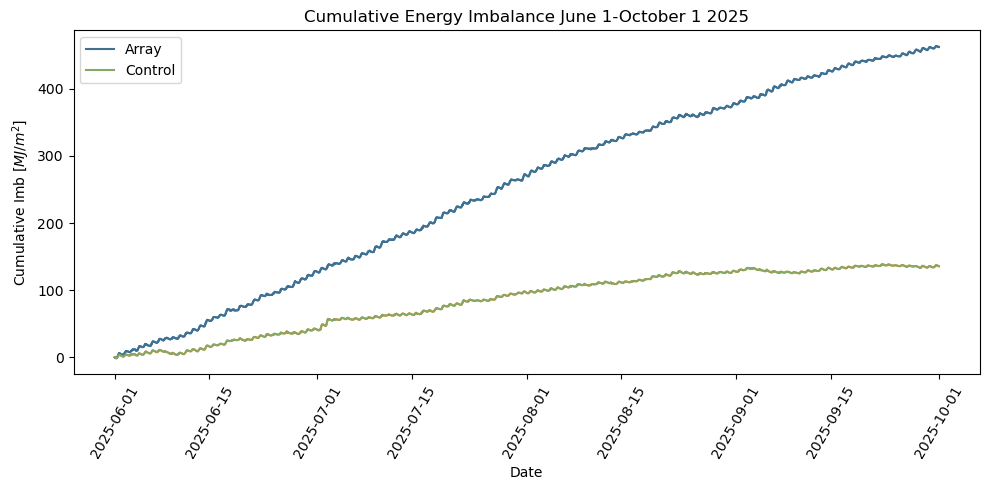

In [6]:
#Cumulative plot - hightlight section under H2O flux of CO2 flux to switch variable

#unit conversion factor
unit_conv = 60*30*1e-6 #W/m^2 * 60 s/min * 30 min/hh * 1 MJ/1e6J

Evars = {
    'H':[-200, 600, -1],
    'LE': [-100, 700, -1],
    'SWin': [-1, 1300, 1],
    'SWout': [-1, 1300, -1],
    'LWin': [50, 600, 1],
    'LWout': [100, 750, -1],
}

EdatA = pd.DataFrame()
EdatC = pd.DataFrame()
for var in Evars:
    minval = Evars[var][0]
    maxval = Evars[var][1]
    sm = Evars[var][2] #sign multiplier
    EdatA[var] = KSA_all[var].where((KSA_all[var]>=minval)&(KSA_all[var]<=maxval))*sm
    EdatC[var] = KSC_all[var].where((KSC_all[var]>=minval)&(KSC_all[var]<=maxval))*sm

Imb_KSA = EdatA.sum(axis = 1)
Imb_KSC = EdatC.sum(axis = 1)

#plot
figsize = (10,5)
plt.figure(figsize = figsize)
KSA_cum = Imb_KSA.cumsum()*unit_conv
KSC_cum = Imb_KSC.cumsum()*unit_conv
plt.plot(KSA_cum)
plt.plot(KSC_cum)


plt.title('Cumulative Energy Imbalance June 1-October 1 2025')
plt.ylabel('Cumulative Imb [$MJ/m^2$]')
plt.xlabel('Date')

plt.plot(KSA_cum, label = 'Array', c = colorlist[0])
plt.plot(KSC_cum, label = 'Control', c = colorlist[1])
plt.xticks(rotation = 60);
plt.legend()

save_base_path = r'C:\Users\emily\Documents\Grad_School\Research\Agrivoltaics\Figures\AFlux_2025\\'
plt.tight_layout()

plt.savefig(save_base_path +'Imb_cumulative.png', bbox_inches=Bbox([[0,-.2],figsize]))

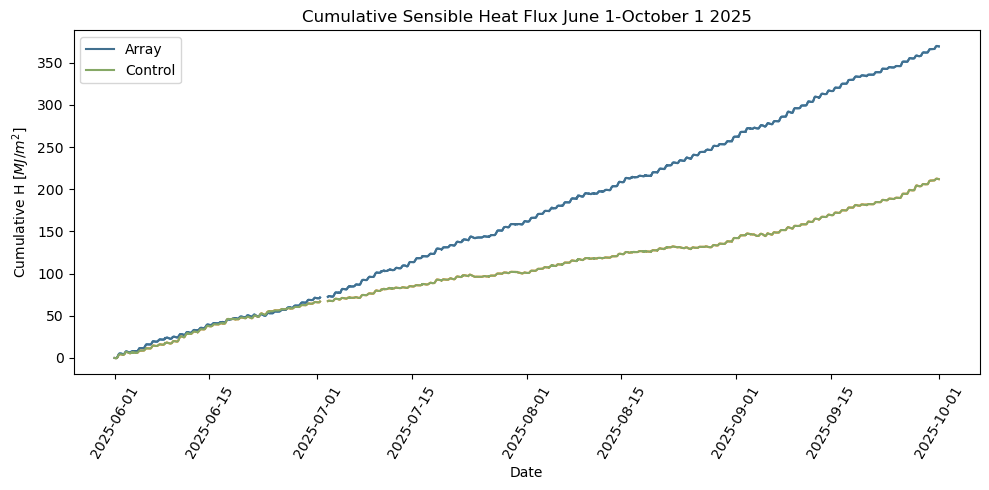

In [7]:
#Cumulative plot - hightlight section under H2O flux of CO2 flux to switch variable

#Change dates and variable
sd = dt.datetime(2025,6,1)
ed = dt.datetime(2025, 10, 1)

#H2O flux
# varname = 'Evapotranspiration'
# varname_short = 'ET'
# cum_units = '[$mm$]'
# var = 'h2o_flux'
# LE_cf =  1/2.5e3 * 1/18 * 1000 #convert LE [W/m^2] to h2o flux [mmol/m^2/s] = 1/Latend heat of vaporization at 0C = 1/2.5e3 J/g * 1/1 mol/18 g* 1000mmol/mol
# min_val = -100*LE_cf# DFC limits(from Ankur)
# max_val = 700*LE_cf #From DFC limits (from Ankur)
# unit_conv = 60 * 30 * 1e-3 * 18 *1e-3#[mmol/m^2/s] * 60 s/min * 30 min * 1 mol/10^3 mmol * 18 g/mol * 1kg/1000g * 1m^3/1000kg * 1000mm/m = [mm]- water vapor

# #CO2 Flux
# varname = 'NEE'
# varname_short = varname
# cum_units = '[$g/m^2$]'
# var = 'co2_flux'
# min_val = -100 #From DFC limits(from AFlux?)
# max_val = 100 #From DFC limits(from AFlux?)
# unit_conv = 60 * 30 * 1e-6 * 44 #[micromol/m^2/s] * 60 s/min * 30 min * 1 mol/10^6 micromol * 44 g/mol  - CO2

#H Flux
varname = 'Sensible Heat Flux'
varname_short = 'H'
cum_units = '[$MJ/m^2$]'
var = 'H'
min_val = -100 #From DFC limits(from AFlux?)
max_val = 700 #From DFC limits(from AFlux?)
unit_conv = 60 * 30 * 1e-6 #[micromol/m^2/s] * 60 s/min * 30 min * 1 mol/10^6 micromol * 44 g/mol  - CO2

#Filter based on min and max vals
val_filter = (KSA[var]>=min_val) & (KSA[var]<=max_val) & (KSC[var]>=min_val) & (KSC[var]<=max_val)


#plot
figsize = (10,5)
plt.figure(figsize = figsize)
KSA_cum = KSA[var].where(val_filter)[sd:ed].cumsum()*unit_conv
KSC_cum = KSC[var].where(val_filter)[sd:ed].cumsum()*unit_conv
plt.plot(KSA_cum)
plt.plot(KSC_cum)


plt.title('Cumulative ' +  varname +  ' June 1-October 1 2025')
plt.ylabel('Cumulative ' + varname_short  + ' ' + cum_units)
plt.xlabel('Date')

plt.plot(KSA_cum, label = 'Array', c = colorlist[0])
plt.plot(KSC_cum, label = 'Control', c = colorlist[1])
plt.xticks(rotation = 60);
# plt.annotate(text = 'Vegetation \n mowed', xy = (dt.datetime(2025, 7, 2), -270), 
#              xytext= (dt.datetime(2025, 6, 5), -330), arrowprops=dict(facecolor='black', arrowstyle='->'))

# plt.annotate(text = 'Vegetation \n mowed?', xy = (dt.datetime(2025, 8, 6, 18), -560), 
#              xytext= (dt.datetime(2025, 8, 2), -470), arrowprops=dict(facecolor='black', arrowstyle='->'))

# plt.annotate(text = 'Glyphosate \n applied', xy = (dt.datetime(2025, 8, 10, 12), -545), 
#              xytext= (dt.datetime(2025, 8, 21), -535), arrowprops=dict(facecolor='black', arrowstyle='->'))
plt.legend();

save_base_path = r'C:\Users\emily\Documents\Grad_School\Research\Agrivoltaics\Figures\AFlux_2025\\'
plt.tight_layout()

plt.savefig(save_base_path + varname_short + '_cumulative.png', bbox_inches=Bbox([[0,-.2],figsize]))

## Day cycles and averages of met Vars

### Functions

In [8]:
#functions for averaging data - diel cycle and 1 day average, day average can also be used with different frequency input as avg_time
def day_cyc(data, sd = 0, ed = 0, minval = float('-inf'), maxval = float('inf')):
    if sd == 0:
        sd = data.index.min()
    if ed == 0:
        ed = data.index.max()
    if type(data) == pd.core.frame.DataFrame:
        data = data.select_dtypes('number')
    data = data[sd:ed].where((data>minval)&(data<maxval))
    avg = data.groupby(data.index.time).mean()
    
    return avg 

def day_avg(data, sd = 0, ed = 0, minval = float('-inf'), maxval = float('inf'), avg_time = '1d'):
    if sd == 0:
        sd = data.index.min()
    if ed == 0:
        ed = data.index.max()
    if type(data) == pd.core.frame.DataFrame:
        data = data.select_dtypes('number')
    data = data[sd:ed].where((data>minval)&(data<maxval))
    avg = data.resample(avg_time).mean()
    return avg

In [9]:
# #set start and end date to incorporate into averages
# sd = dt.datetime(2025, 6, 1)
# ed = dt.datetime(2025, 10, 1)

# #diel cycle
# KSA_day_cyc = day_cyc(KSA[sd:ed])
# KSA_bm_day_cyc = day_cyc(KSA_bm[sd:ed])
# KSC_day_cyc = day_cyc(KSC[sd:ed])
# KSC_bm_day_cyc = day_cyc(KSC_bm[sd:ed])

# #1 day average
# KSA_day_avg = day_avg(KSA[sd:ed])
# KSC_day_avg = day_avg(KSC[sd:ed])

# #7 day average
# KSA_week_avg = day_avg(KSA[sd:ed], avg_time = '7d')
# KSC_week_avg = day_avg(KSC[sd:ed],  avg_time = '7d')


KSA columns
- air_temperature
- air_pressure
- water_vapor_density
- e
- es
- specific_humidity
- RH
- VPD


### Air Temeperature

<>:10: SyntaxWarning: invalid escape sequence '\c'
<>:10: SyntaxWarning: invalid escape sequence '\c'
C:\Users\emily\AppData\Local\Temp\ipykernel_23700\1151596754.py:10: SyntaxWarning: invalid escape sequence '\c'
  units = '[$^\circ$C]'


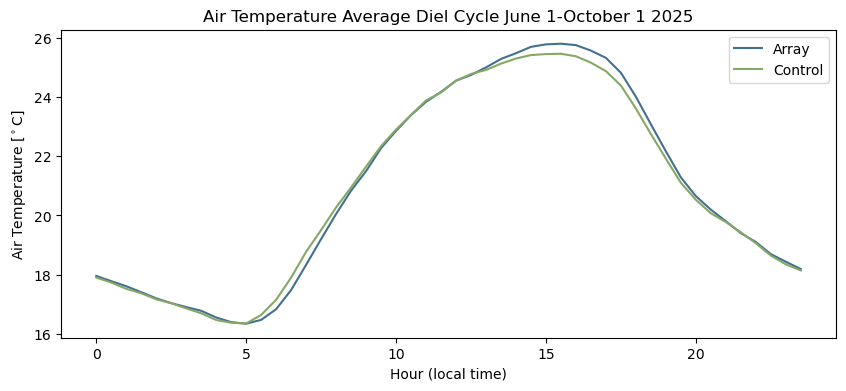

In [10]:
#Start and end date
sd = dt.datetime(2025,6,1)
ed = dt.datetime(2025, 10, 1)


#Air temperature diel cycle
var = 'air_temperature'
var2 = 'Ta_1_1_1'
varname = 'Air Temperature'
units = '[$^\circ$C]'


plt.figure(figsize = (10, 4))
#EddyPro output 
# plt.plot(hh_index, day_cyc(KSA[var], sd, ed, minval = 240, maxval = 320).values-273.15, label = 'KSA EP', c = "#AC254E")
# plt.plot(hh_index, day_cyc(KSC[var], sd, ed, minval = 240, maxval = 320).values-273.15, label = 'KSC EP', c = "#DB8641")

#Raw temp
plt.plot(hh_index, day_cyc(KSA_bm[var2], sd, ed, -30, 50).values, label = 'Array', c = colorlist[0])
plt.plot(hh_index, day_cyc(KSC_bm[var2], sd, ed, -30, 50).values, label = 'Control', c = colorlist[1])


plt.xlabel('Hour (local time)')
plt.ylabel(varname + ' ' + units)
plt.title(varname + ' Average Diel Cycle June 1-October 1 2025')
          
plt.legend()
plt.savefig(save_base_path + 'TA_diel_cyc_avg.png')
# plt.savefig(save_base_path + 'SWin_diel_cyc_avg.png')


<>:9: SyntaxWarning: invalid escape sequence '\c'
<>:13: SyntaxWarning: invalid escape sequence '\c'
<>:9: SyntaxWarning: invalid escape sequence '\c'
<>:13: SyntaxWarning: invalid escape sequence '\c'
C:\Users\emily\AppData\Local\Temp\ipykernel_23700\3132610958.py:9: SyntaxWarning: invalid escape sequence '\c'
  axs[0].set_ylabel('Temperature [$^\circ$C]');
C:\Users\emily\AppData\Local\Temp\ipykernel_23700\3132610958.py:13: SyntaxWarning: invalid escape sequence '\c'
  axs[1].set_ylabel('Temperature Difference [$^\circ$C] \n (KSA - KSC)' )


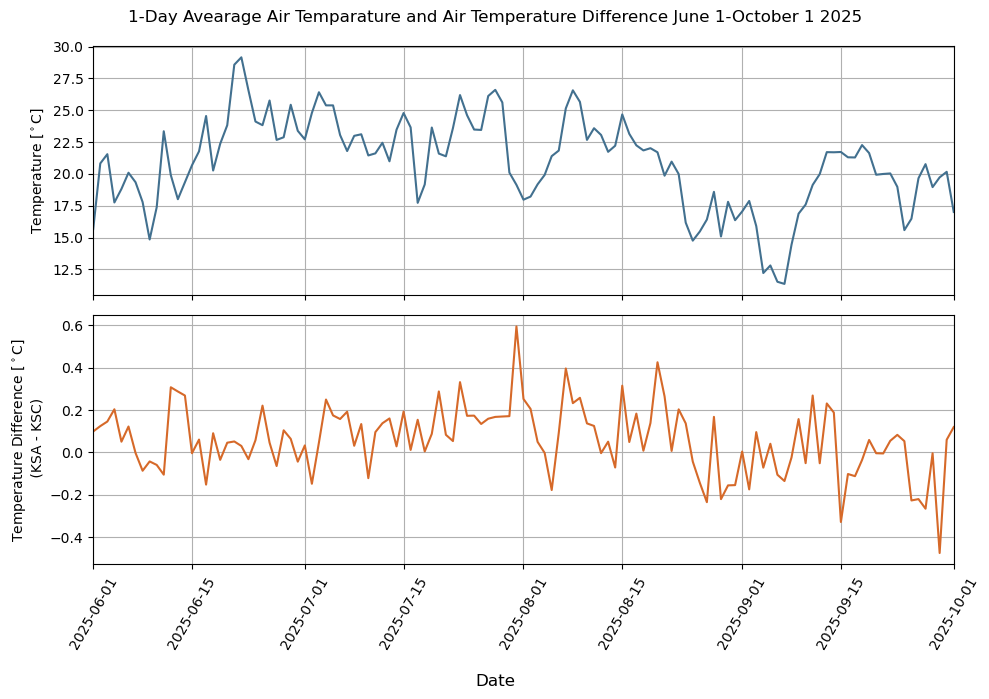

In [11]:
var = 'Ta_1_1_1'
varname = 'Air Temperature'

fig, axs = plt.subplots(2, 1, figsize = (10, 7), sharex = True)
KSA_day = day_avg(KSA_bm[var], sd, ed)
KSC_day = day_avg(KSC_bm[var], sd, ed)

axs[0].plot (KSA_day, c = colorlist[0])
axs[0].set_ylabel('Temperature [$^\circ$C]');


axs[1].plot(KSA_day - KSC_day, c = colorlist[3])
axs[1].set_ylabel('Temperature Difference [$^\circ$C] \n (KSA - KSC)' )

fig.supxlabel('Date')
plt.xticks(rotation = 60);

fig.suptitle('1-Day Avearage Air Temparature and Air Temperature Difference June 1-October 1 2025')
plt.xlim(sd, ed)
axs[0].grid()
axs[1].grid()
plt.tight_layout()
plt.savefig(save_base_path + 'TA_and_TA_diff_1day_avg.png')

### Energy Fluxes

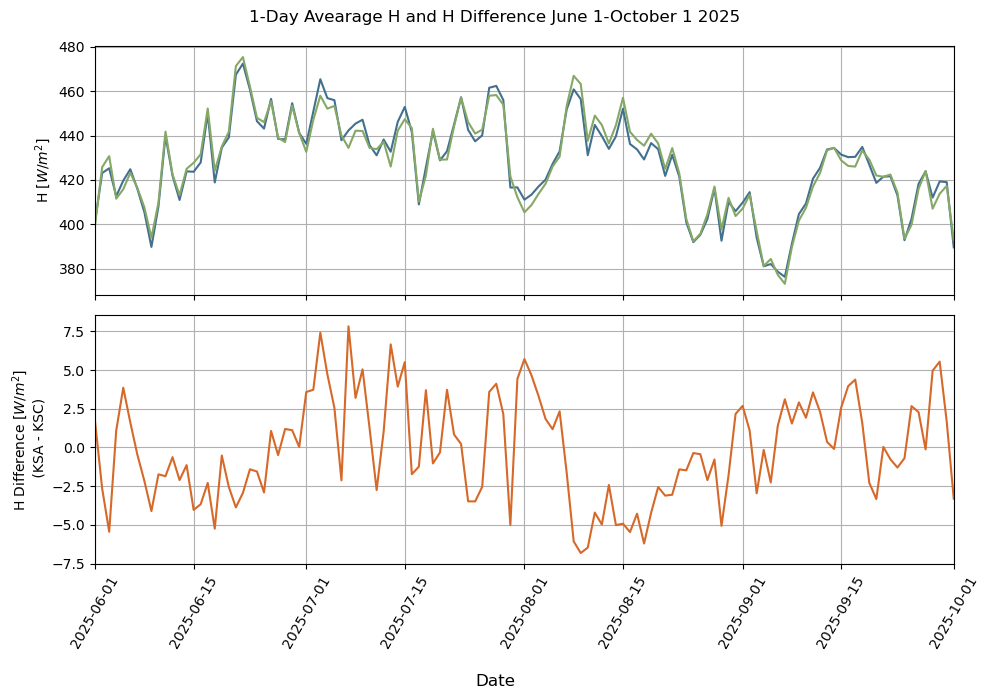

In [12]:
var = 'LWout'
varname = 'Sensible Heat Flux'

fig, axs = plt.subplots(2, 1, figsize = (10, 7), sharex = True)
KSA_day = day_avg(KSA_all[var], sd, ed, minval = -200, maxval = 600)
KSC_day = day_avg(KSC_all[var], sd, ed, minval = -200, maxval = 600)

axs[0].plot (KSA_day, c = colorlist[0])
axs[0].plot (KSC_day, c = colorlist[1])
axs[0].set_ylabel('H [$W/m^2$]');


axs[1].plot(KSA_day - KSC_day, c = colorlist[3])
axs[1].set_ylabel('H Difference [$W/m^2$] \n (KSA - KSC)' )

fig.supxlabel('Date')
plt.xticks(rotation = 60);

fig.suptitle('1-Day Avearage H and H Difference June 1-October 1 2025')
plt.xlim(sd, ed)
axs[0].grid()
axs[1].grid()
plt.tight_layout()
plt.savefig(save_base_path + var + '_and_' + var + '_diff_1day_avg.png')

In [13]:
KSA_all.columns

Index(['filename', 'date', 'time', 'DOY', 'daytime', 'file_records',
       'used_records', 'Tau', 'qc_Tau', 'H', 'qc_H', 'LE', 'qc_LE', 'co2_flux',
       'qc_co2_flux', 'h2o_flux', 'qc_h2o_flux', 'H_strg', 'LE_strg',
       'co2_strg', 'h2o_strg', 'co2_v-adv', 'h2o_v-adv', 'co2_molar_density',
       'co2_mole_fraction', 'co2_mixing_ratio', 'co2_time_lag',
       'co2_def_timelag', 'h2o_molar_density', 'h2o_mole_fraction',
       'h2o_mixing_ratio', 'h2o_time_lag', 'h2o_def_timelag',
       'sonic_temperature', 'air_temperature', 'air_pressure', 'air_density',
       'air_heat_capacity', 'air_molar_volume', 'ET', 'water_vapor_density',
       'e', 'es', 'specific_humidity', 'RH', 'VPD', 'Tdew', 'u_unrot',
       'v_unrot', 'w_unrot', 'u_rot', 'v_rot', 'w_rot', 'wind_speed',
       'max_wind_speed', 'wind_dir', 'yaw', 'pitch', 'roll', 'u*', 'TKE', 'L',
       '(z-d)/L', 'bowen_ratio', 'T*', 'model', 'x_peak', 'x_offset', 'x_10%',
       'x_30%', 'x_50%', 'x_70%', 'x_90%', 'un_Tau', 'T

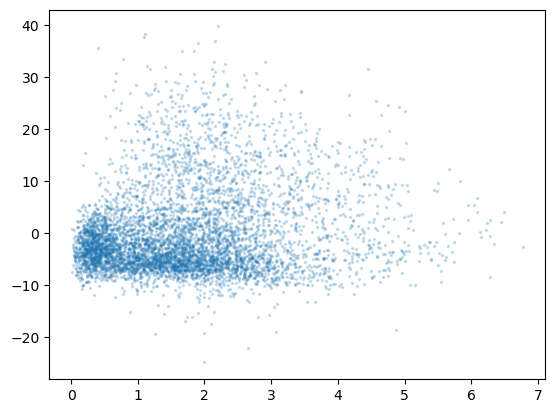

In [14]:
LW_diff = KSA_all['LWout'] - KSC_all['LWout']
xvar = 'wind_speed'
xdiff = KSA_all[xvar]# - KSC_all[xvar]
plt.scatter(xdiff, LW_diff, alpha = 0.2, s = 2)


## Light Data

In [15]:
# Setup data
#Dates for averaging
# sd = dt.datetime(2025, 7, 28)
# ed = dt.datetime(2025, 8, 5)
sd = dt.datetime(2025, 6, 1)
ed = dt.datetime(2025, 10, 1)
ed_ex = ed + dt.timedelta(days = 5) #extended datetime (needed for multi-day avg) 

#Set negative radiation values to 0
sb = sb.map(lambda x: 0 if x <0 else x)[sd:ed_ex]
Sdir_frac = sb.Sbeam/sb.Stot #Ratio of beam to total
Sdir_frac = Sdir_frac.where(Sdir_frac<=1)
KSA_SWin = KSA_bm['SWin'].map(lambda x: 0 if x <0 else x)[sd:ed_ex]
KSA_flux = KSA[['co2_flux', 'h2o_flux']][sd:ed_ex]
KSC_flux = KSC[['co2_flux', 'h2o_flux']][sd:ed_ex]

#Diel cycle
sb_day_cyc = day_cyc(sb, sd, ed, 0, 1300) #average diel cycle of sb data
Sdir_frac_day_cyc = sb_day_cyc.Sbeam/sb_day_cyc.Stot
Sdir_frac_day_cyc = Sdir_frac_day_cyc.where(Sdir_frac_day_cyc<1)
KSA_bm_day_cyc = day_cyc(KSA_SWin, sd, ed)

#1-day avg
avg_per = '1d'
sb_day_avg = day_avg(sb, sd, ed_ex, 0, 1300, avg_time = avg_per) #sb data
Sdir_frac_day_avg = sb_day_avg.Sbeam/sb_day_avg.Stot #Ratio of beam to total
Sdir_frac_day_avg = Sdir_frac_day_avg.where(Sdir_frac_day_avg<=1)
KSA_SWin_day_avg = day_avg(KSA_SWin, sd, ed_ex, avg_time = avg_per) #KSA biomet data
KSA_flux_day_avg = day_avg(KSA_flux, sd, ed, avg_time = avg_per)
KSC_flux_day_avg = day_avg(KSC_flux, sd, ed, avg_time = avg_per)


#multi-day avg
avg_per = '3d'
sb_xday_avg = day_avg(sb, sd, ed_ex,0, 1300, avg_time = avg_per) #sb data
Sdir_frac_xday_avg = sb_xday_avg.Sbeam/sb_xday_avg.Stot #Ratio of beam to total
Sdir_frac_xday_avg = Sdir_frac_xday_avg.where(Sdir_frac_xday_avg<=1) #Get rid of any timesteps where direct frac >1
KSA_SWin_xday_avg = day_avg(KSA_SWin, sd, ed_ex, avg_time = avg_per) #KSA biomet data


#### Diel Cycle of SWin components

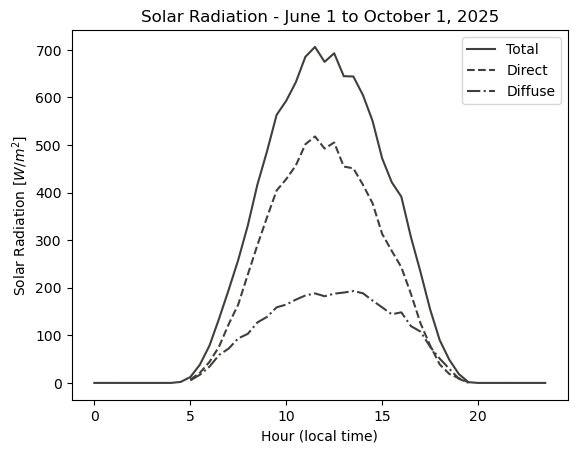

In [16]:
plt.plot(hh_index, KSA_bm_day_cyc, c= colorlist[2], label = 'Total')
plt.plot(hh_index, KSA_bm_day_cyc*Sdir_frac_day_cyc, c= colorlist[2], linestyle = '--', label = 'Direct')
plt.plot(hh_index, KSA_bm_day_cyc*(1-Sdir_frac_day_cyc), c = colorlist[2], linestyle = '-.', label = 'Diffuse')

plt.xlabel('Hour (local time)');
plt.ylabel('Solar Radiation [$W/m^2$]');
plt.title('Solar Radiation - June 1 to October 1, 2025')
plt.legend()
plt.savefig(save_base_path + 'SWin_dir_and_diff_mean_diel_cycle.png')

#### Timeseries of SWin components

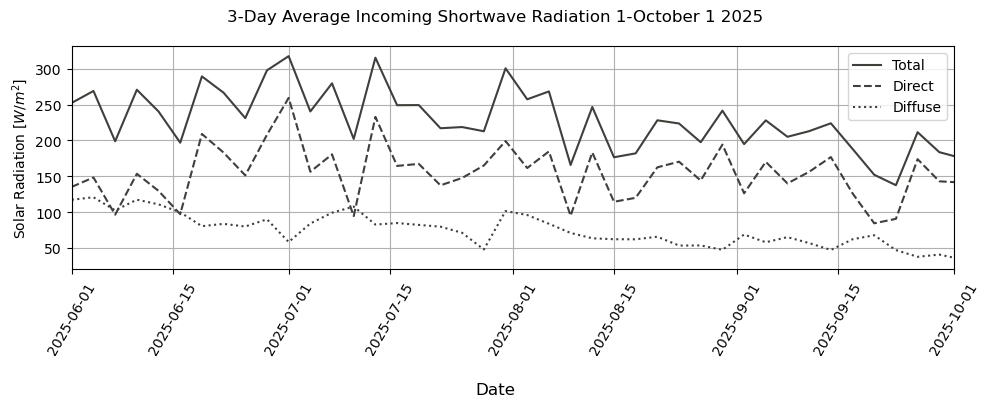

In [17]:
var = 'SWin'
varname = '$SW_{in}$'
units = '[$W/m^2$]'


#Raw temp
fig, ax = plt.subplots(1, 1, figsize = (10, 4), sharex = True)


ax.plot(KSA_SWin_xday_avg, c = colorlist[2], label = 'Total')
ax.plot(KSA_SWin_xday_avg*Sdir_frac_xday_avg, c = colorlist[2], linestyle = '--', label = 'Direct')
ax.plot(KSA_SWin_xday_avg*(1-Sdir_frac_xday_avg), c = colorlist[2], linestyle = ':', label = 'Diffuse')
ax.set_ylabel('Solar Radiation [$W/m^2$]');



fig.supxlabel('Date')
plt.xticks(rotation = 60);

fig.suptitle('3-Day Average Incoming Shortwave Radiation 1-October 1 2025')
plt.xlim(sd, ed)
ax.grid()
plt.legend()
plt.tight_layout()
plt.savefig(save_base_path + 'SWin_dir_and_diff_3day_avg_timeseries.png')

#### Cumulative SW_in

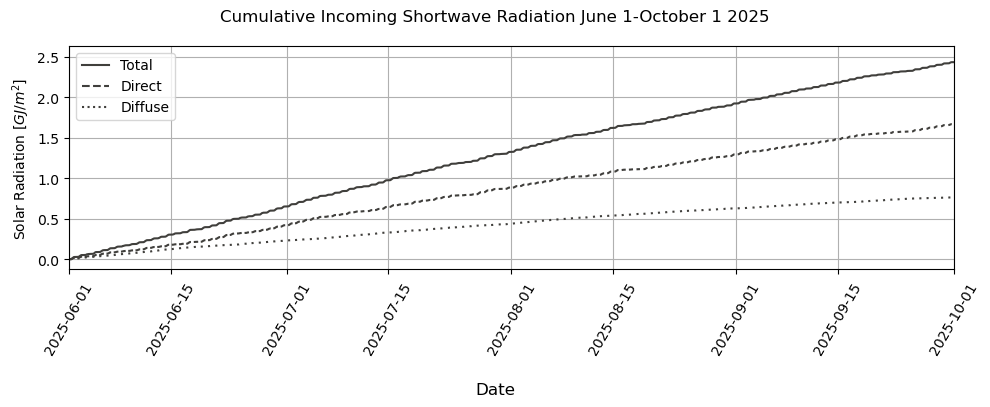

In [18]:
var = 'SWin'
varname = '$SW_{in}$'
units = '[$W/m^2$]'

cf = 60*30/1e9

#Raw temp
fig, ax = plt.subplots(1, 1, figsize = (10, 4), sharex = True)


ax.plot (KSA_SWin.cumsum()*cf, c = colorlist[2], label = 'Total')
ax.plot ((KSA_SWin*Sdir_frac).cumsum()*cf, c = colorlist[2], linestyle = '--', label = 'Direct')
ax.plot ((KSA_SWin*(1-Sdir_frac)).cumsum()*cf, c = colorlist[2], linestyle = ':', label = 'Diffuse')
ax.set_ylabel('Solar Radiation [$GJ/m^2$]');


fig.supxlabel('Date')
plt.xticks(rotation = 60);

fig.suptitle('Cumulative Incoming Shortwave Radiation June 1-October 1 2025')
plt.xlim(sd, ed)
ax.grid()
plt.legend()
plt.tight_layout()
plt.savefig(save_base_path + 'SWin_dir_and_cumulative_timeseries.png')

#### NEE v SW comps

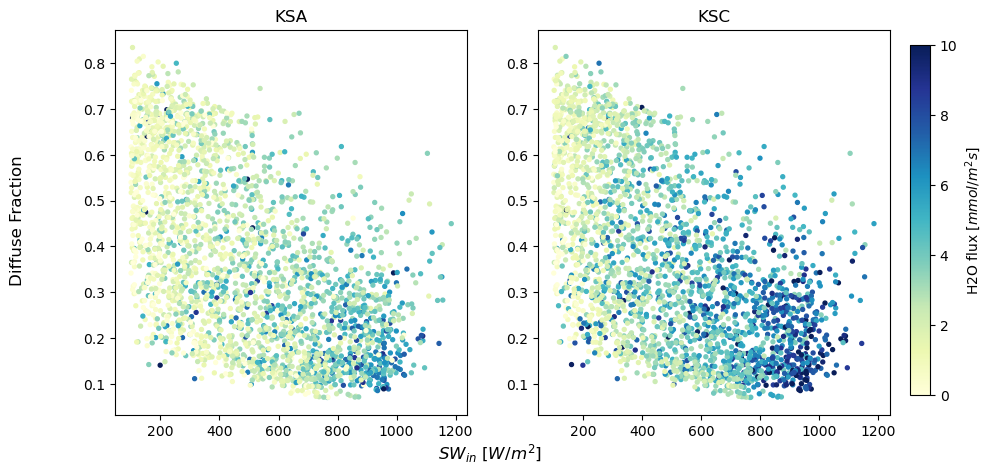

In [19]:
fig, axs = plt.subplots(1, 2, figsize = (10, 5))
var = 'h2o_flux'
filter = KSA_SWin[sd:ed]>100
towdatlist = [KSA_flux, KSC_flux]
towlist = ['KSA', 'KSC']
for i in range(2):
    towdat = towdatlist[i][var]
    ax = axs[i]
    cb = ax.scatter(KSA_SWin[sd:ed][filter], 
            1-Sdir_frac[sd:ed][filter], 
            c = towdat[sd:ed][filter],
            s = 8,
            cmap = 'YlGnBu',
            vmin = 0,
            vmax = 10)
    ax.set_title(towlist[i])


fig.supylabel('Diffuse Fraction')
fig.supxlabel('$SW_{in}$ [$W/m^2$]')
cbar_ax = fig.add_axes([.92, 0.15, 0.02, 0.7])
fig.colorbar(cb, cbar_ax, label = 'H2O flux [$mmol/{m^2 s}$]')

# plt.tight_layout()
plt.savefig(save_base_path + 'SWin_dirfrac_and_h2oflux.png')

Text(0.02, 0.5, 'CO2 Flux Difference')

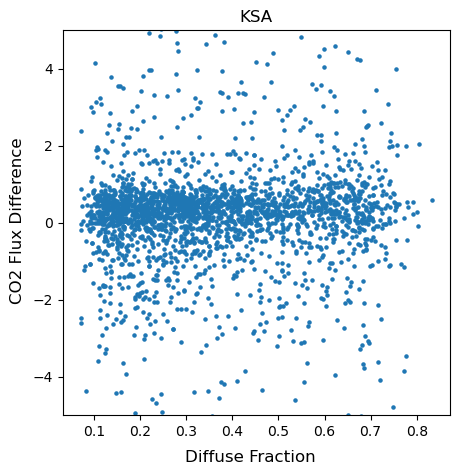

In [46]:
fig, ax = plt.subplots(figsize = (5, 5))
var = 'co2_flux'
filter = KSA_SWin[sd:ed]>100
towdatlist = [KSA_flux, KSC_flux]
towlist = ['KSA', 'KSC']

towdat = towdatlist[i][var]
cb = ax.scatter(1-Sdir_frac[sd:ed][filter], 
        (KSC[var][sd:ed][filter] - KSA[var][sd:ed][filter])/KSC[var][sd:ed][filter],
        s = 5)
ax.set_title(towlist[i])

plt.ylim(-5, 5)
fig.supxlabel('Diffuse Fraction')
fig.supylabel('CO2 Flux Difference')
# cbar_ax = fig.add_axes([.92, 0.15, 0.02, 0.7])
# fig.colorbar(cb, cbar_ax, label = 'H2O flux [$mmol/{m^2 s}$]')


<>:21: SyntaxWarning: invalid escape sequence '\m'
<>:21: SyntaxWarning: invalid escape sequence '\m'
C:\Users\emily\AppData\Local\Temp\ipykernel_23700\3646695234.py:21: SyntaxWarning: invalid escape sequence '\m'
  fig.colorbar(cb, cbar_ax, label = 'CO2 flux [$\mu mol/{m^2 s}$]')


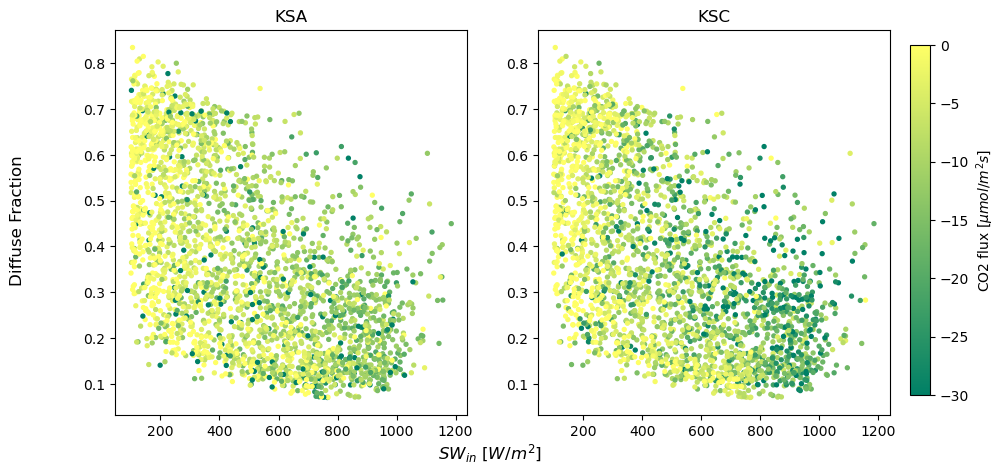

In [20]:
fig, axs = plt.subplots(1, 2, figsize = (10, 5))
var = 'co2_flux'
filter = KSA_SWin[sd:ed]>100
towdatlist = [KSA_flux, KSC_flux]
towlist = ['KSA', 'KSC']
for i in range(2):
    towdat = towdatlist[i][var]
    ax = axs[i]
    cb = ax.scatter(KSA_SWin[sd:ed][filter], 
            1-Sdir_frac[sd:ed][filter], 
            c = towdat[sd:ed][filter],
            s = 8,
            cmap = 'summer',
            vmin = -30,
            vmax = 0)
    ax.set_title(towlist[i])

fig.supylabel('Diffuse Fraction')
fig.supxlabel('$SW_{in}$ [$W/m^2$]')
cbar_ax = fig.add_axes([.92, 0.15, 0.02, 0.7])
fig.colorbar(cb, cbar_ax, label = 'CO2 flux [$\mu mol/{m^2 s}$]')
plt.savefig(save_base_path + 'SWin_dirfrac_and_co2flux.png')

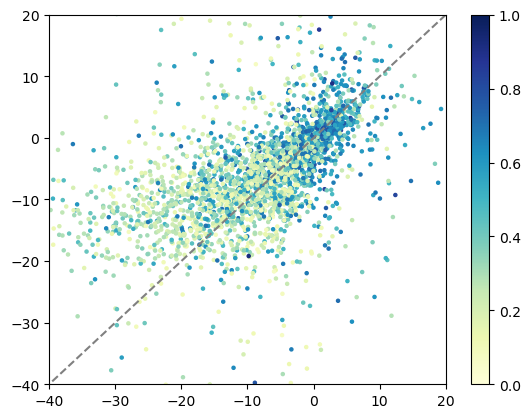

In [21]:
var = 'co2_flux'
filter = KSA_SWin[sd:ed]>10
colorvar = (1-Sdir_frac)[sd:ed][filter] 
plt.scatter(KSC_flux[var][sd:ed][filter], 
            KSA_flux[var][sd:ed][filter],
            c = colorvar, 
            s = 5,
            cmap = 'YlGnBu',
            vmin = 0,
            vmax = 1)

plt.xlim(-40, 20)
plt.ylim(-40, 20)
plt.plot([-100, 100], [-100, 100], c = 'gray', linestyle = '--')
plt.colorbar()

#### Smoke effect on NEE

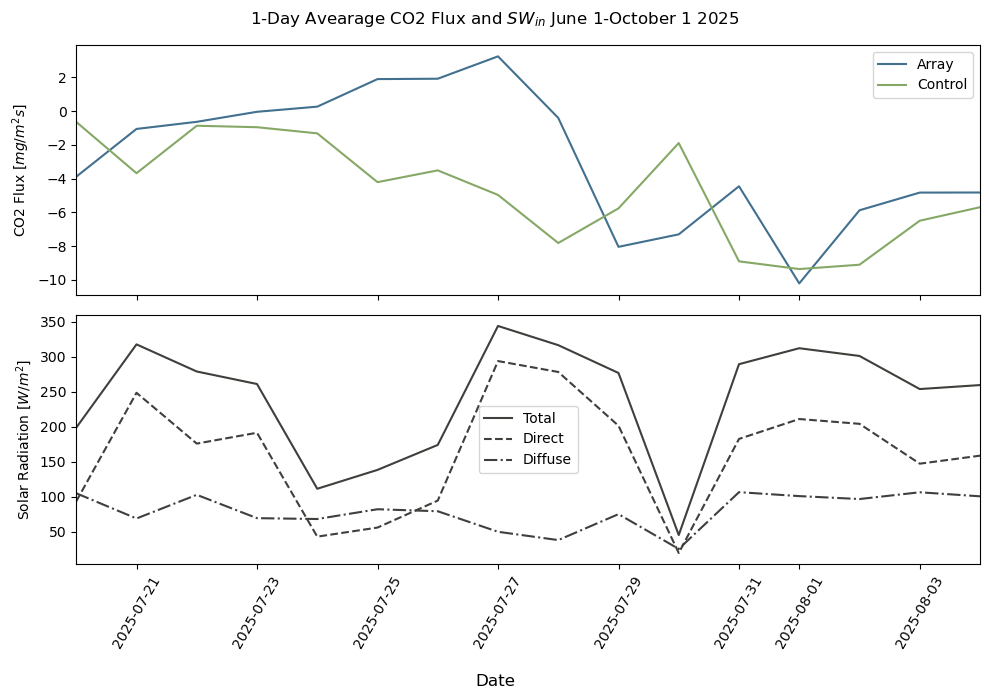

In [22]:
var = 'SWin'
varname = '$SW_{in}$'
units = '[$W/m^2$]'
sd_cut = dt.datetime(2025, 7, 20)
ed_cut = dt.datetime(2025, 8, 4)

#Raw temp
fig, axs = plt.subplots(2, 1, figsize = (10, 7), sharex = True)

axs[0].plot(KSA_flux_day_avg['co2_flux'][sd_cut:ed_cut], c = colorlist[0], label = 'Array')
axs[0].plot(KSC_flux_day_avg['co2_flux'][sd_cut:ed_cut], c = colorlist[1], label = 'Control')
axs[0].legend()
axs[0].set_ylabel('CO2 Flux [$mg/{m^2 s}$]')
axs[1].plot(KSA_SWin_day_avg[sd_cut:ed_cut], c = colorlist[2], label = 'Total')
axs[1].plot((KSA_SWin_day_avg*Sdir_frac_day_avg)[sd_cut:ed_cut], c = colorlist[2], linestyle = '--', label = 'Direct')
axs[1].plot((KSA_SWin_day_avg*(1-Sdir_frac_day_avg))[sd_cut:ed_cut], c = colorlist[2], linestyle = '-.', label = 'Diffuse')
axs[1].set_ylabel('Solar Radiation [$W/m^2$]');
axs[1].legend()


fig.supxlabel('Date')
plt.xticks(rotation = 60);

fig.suptitle('1-Day Avearage CO2 Flux and $SW_{in}$ June 1-October 1 2025')
plt.xlim(sd_cut, ed_cut)
# axs[1].grid()
plt.tight_layout()
plt.savefig(save_base_path + 'CO2_flux_and_SWin.png')

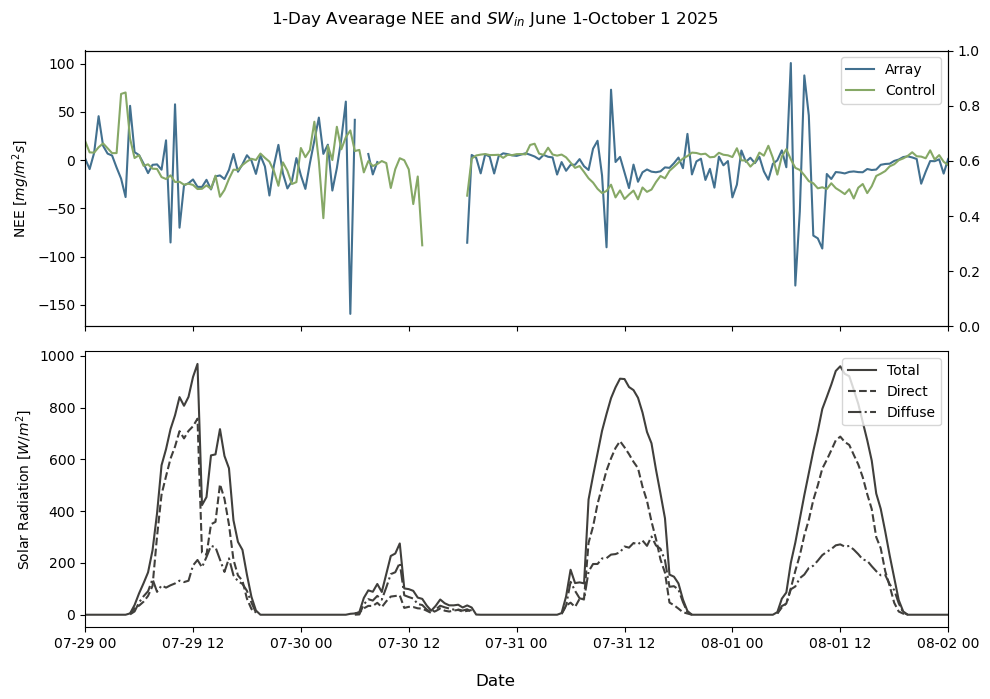

In [23]:
var = 'co2_flux'
varname = '$SW_{in}$'
sd_cut = dt.datetime(2025, 7, 29)
ed_cut = dt.datetime(2025, 8, 2)

#Raw temp
fig, axs = plt.subplots(2, 1, figsize = (10, 7), sharex = True)

axs[0].plot(KSA_flux[var][sd_cut:ed_cut], c = colorlist[0], label = 'Array')
axs[0].plot(KSC_flux[var][sd_cut:ed_cut], c = colorlist[1], label = 'Control')
axs[0].legend()
axs[0].set_ylabel('NEE [$mg/{m^2 s}$]')
axs2 = axs[0].twinx()
# axs2.plot(KSA[sd_cut:ed_cut]['qc_co2_flux'], c= colorlist[3], zorder = 0)

axs[1].plot(KSA_SWin[sd_cut:ed_cut], c = colorlist[2], label = 'Total')
axs[1].plot((KSA_SWin*Sdir_frac)[sd_cut:ed_cut], c = colorlist[2], linestyle = '--', label = 'Direct')
axs[1].plot((KSA_SWin*(1-Sdir_frac))[sd_cut:ed_cut], c = colorlist[2], linestyle = '-.', label = 'Diffuse')
axs[1].set_ylabel('Solar Radiation [$W/m^2$]');
axs[1].legend(loc = 'upper right')


fig.supxlabel('Date')
plt.xticks(rotation = 60);

fig.suptitle('1-Day Avearage NEE and $SW_{in}$ June 1-October 1 2025')
plt.xlim(sd_cut, ed_cut)
# axs[1].grid()
plt.tight_layout()
plt.savefig(save_base_path + 'CO2_flux_and_SWin.png')

### VPD

In [24]:
def calc_VPD(TA_C, RH): #TA_C in deg C, RH as percent
    es = 611.2*np.exp(17.67*TA_C/(TA_C+ 243.5)) #Saturation vapor pressure [Pa] - Petty eqn 7.19 (pg 183)
    e = es*RH/100
    VPD = es - e
    return VPD

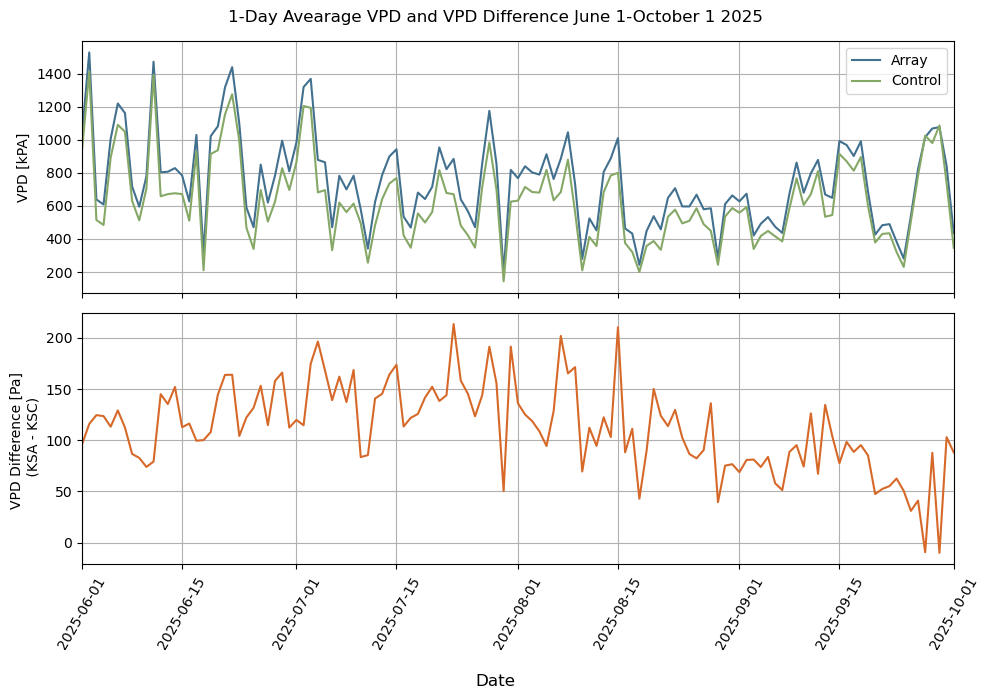

In [25]:

VPD_KSA= calc_VPD(KSA_bm['Ta_1_1_1'], KSA_bm['RH_1_1_1'])
VPD_KSC= calc_VPD(KSC_bm['Ta_1_1_1'], KSC_bm['RH_1_1_1'])
varname = 'Vapor Pressure Deficit'
units = ['Pa']

fig, axs = plt.subplots(2, 1, figsize = (10, 7), sharex = True)
KSA_day = day_avg(VPD_KSA, sd, ed)
KSC_day = day_avg(VPD_KSC, sd, ed)

axs[0].plot (KSA_day, c = colorlist[0], label = 'Array')
axs[0].plot (KSC_day, c = colorlist[1], label = 'Control')
axs[0].set_ylabel('VPD [kPA]');
axs[0].legend()


axs[1].plot(KSA_day - KSC_day, c = colorlist[3])
axs[1].set_ylabel('VPD Difference [Pa] \n (KSA - KSC)' )

fig.supxlabel('Date')
plt.xticks(rotation = 60);

fig.suptitle('1-Day Avearage VPD and VPD Difference June 1-October 1 2025')
plt.xlim(sd, ed)
axs[0].grid()
axs[1].grid()
plt.tight_layout()
plt.savefig(save_base_path + 'VPD_and_VPD_diff_1day_avg.png')

## TKE

### Timeseries

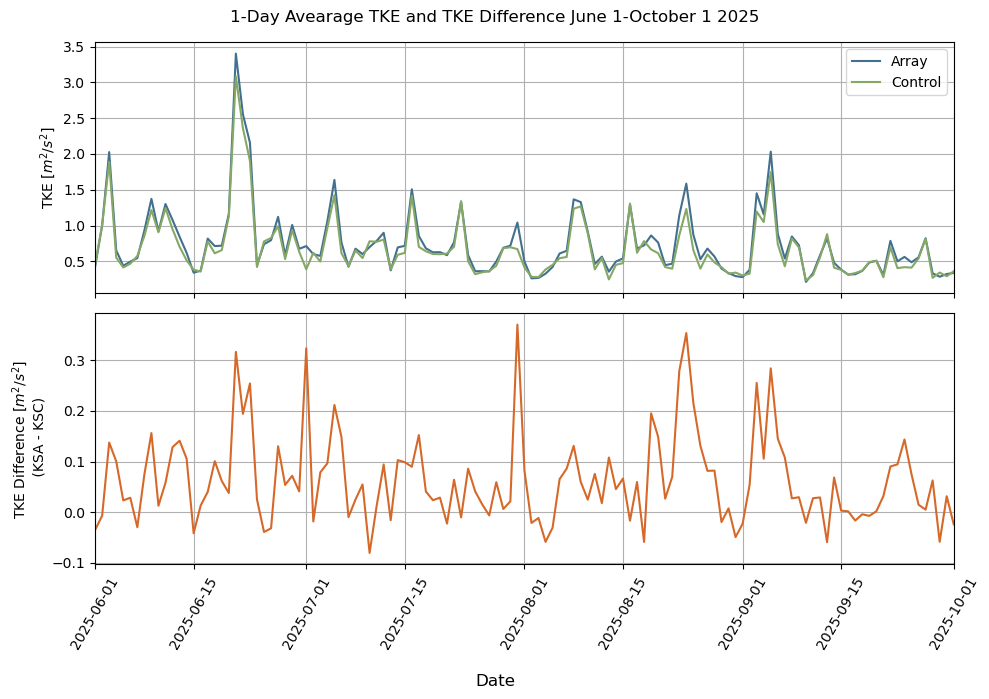

In [26]:

TKE_KSA= KSA['TKE']
TKE_KSC= KSC['TKE']
varname = 'Turbulent Kinetic Energy'
units = ['$m^2/s^2$']

fig, axs = plt.subplots(2, 1, figsize = (10, 7), sharex = True)
KSA_day = day_avg(TKE_KSA, sd, ed)
KSC_day = day_avg(TKE_KSC, sd, ed)

axs[0].plot (KSA_day, c = colorlist[0], label = 'Array')
axs[0].plot (KSC_day, c = colorlist[1], label = 'Control')
axs[0].set_ylabel('TKE [$m^2/s^2$]');
axs[0].legend()


axs[1].plot(KSA_day - KSC_day, c = colorlist[3])
axs[1].set_ylabel('TKE Difference [$m^2/s^2$] \n (KSA - KSC)' )

fig.supxlabel('Date')
plt.xticks(rotation = 60);

fig.suptitle('1-Day Avearage TKE and TKE Difference June 1-October 1 2025')
plt.xlim(sd, ed)
axs[0].grid()
axs[1].grid()
plt.tight_layout()
plt.savefig(save_base_path + 'TKE_and_TKE_diff_1day_avg.png')

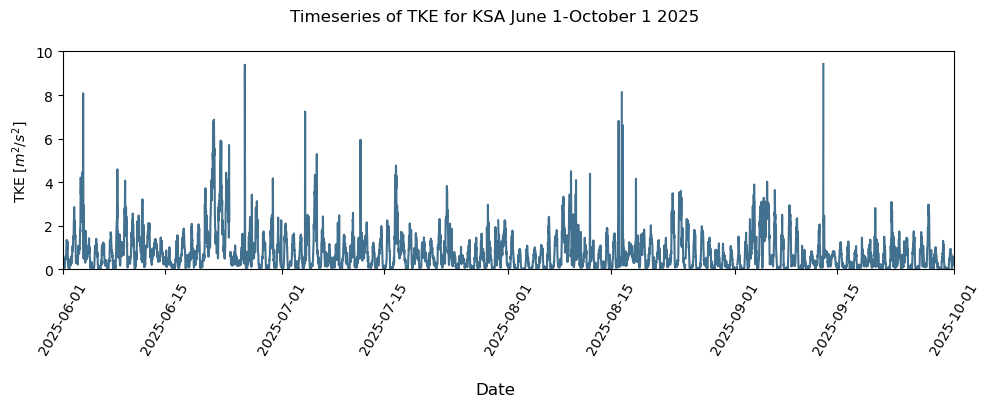

In [27]:
fig, ax = plt.subplots(1, 1, figsize = (10, 4), sharex = True)


ax.plot (TKE_KSA, c = colorlist[0], label = 'Array')
ax.set_ylabel('TKE [$m^2/s^2$]');


# axs[1].plot(KSA_day - KSC_day, c = colorlist[3])
# axs[1].set_ylabel('TKE Difference [$m^2/s^2$] \n (KSA - KSC)' )

fig.supxlabel('Date')
plt.xticks(rotation = 60);

fig.suptitle('Timeseries of TKE for KSA June 1-October 1 2025')
plt.xlim(sd, ed)
ax.set_ylim(0, 10)
# axs[1].set_ylim(0, 10)
ax.grid()
ax.grid()
plt.tight_layout()
plt.savefig(save_base_path + 'TKE_KSA_Timeseries.png')

## Wind Plots

### Setup data

In [28]:
#Function to filter for just day or nighttime values, based on SWin
def dn_filt(data, var, dn, sd = dt.datetime(2025, 6, 1), ed = dt.datetime(2025, 10, 1)):
    data_cut = data[var][sd:ed]
    Sfilt = data['SWin'][sd:ed]
    if dn == 'd':
        filter = Sfilt>=100
    if dn =='n':
        filter = Sfilt<=1
    if dn == 'all':
        filter = Sfilt >= 0 #All valid value
    data_filt = data_cut.where(filter)

    return data_filt


In [29]:
#Group data into bins by wind direction
def grp_dat(data, var, dn, tow, sectors = 8,  sd = dt.datetime(2025, 6, 1), ed = dt.datetime(2025, 10, 1)):
    x = dn_filt(data, 'WD', dn = dn, sd = sd, ed= ed)
    y = dn_filt(data, var, dn = dn, sd = sd, ed = ed)

    # Create bins
    bins_array = np.linspace(0, 360, sectors + 1)
    bins = pd.cut(x, bins=bins_array, right=False) #Group x vals into bins

    y_grpd = y.groupby(bins, observed = False).apply(list).reset_index(name = '0') #Group y into bins

    #Format grouped data
    grpd_data = []
    for idx, row in y_grpd.iterrows():
        for value in row['0']:
            grpd_data.append({'Bin': row.iloc[0], 'Value': value})
            
    # Convert to DataFrame
    grpd_df = pd.DataFrame(grpd_data)
    return grpd_df
    # return y


In [30]:
#Calculate centers of grouping bins
def calc_bin_cents(sectors):
    bins_array = np.linspace(0, 360, sectors + 1)
    bin_cents = np.empty(len(bins_array)-1)
    for i in range(len(bins_array))[0:-1]:
        bin_cent = (bins_array[i+1]+bins_array[i])/2
        bin_cents[i] = bin_cent
        bin_cents_r = bin_cents*np.pi/180 #Bin centers in radians
    return bin_cents_r

#Makes a full circle from the data (adds the first data point on again to end)
def fs(array): 
    array_out = np.append(array, array[0])
    return array_out

### Polar: Median and Quartiles

Text(0.5, 0.98, 'NEE vs. Wind Direction')

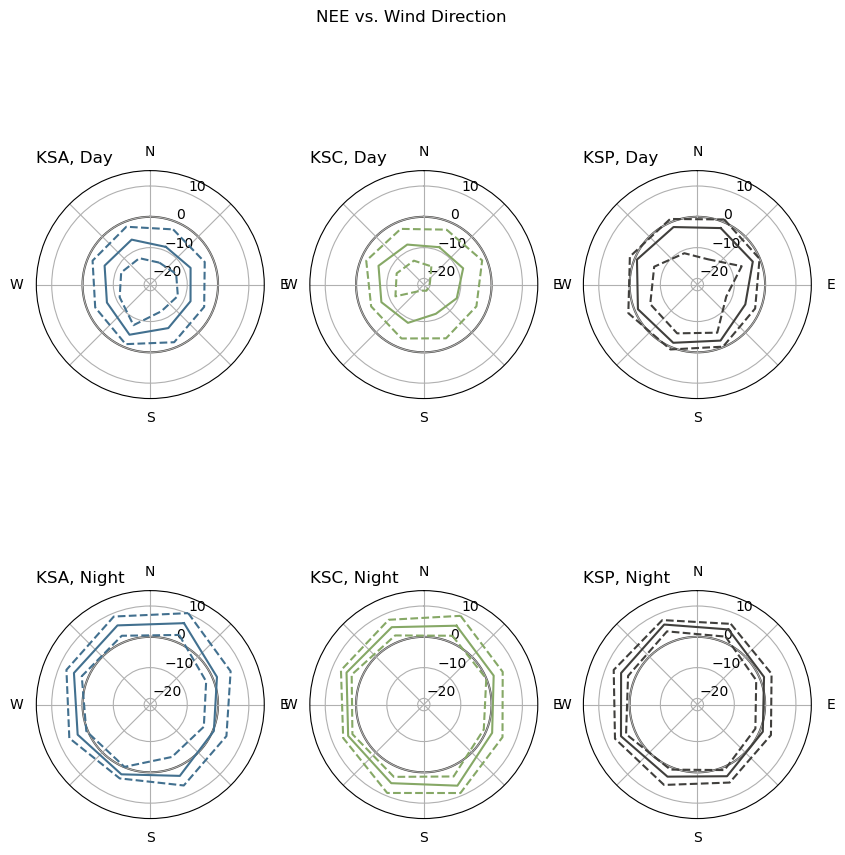

In [31]:
fig, axs = plt.subplots(2, 3, figsize=(10,10), subplot_kw={'projection': 'polar'})
dn = 'all' #d or n for day/night filter
sectors = 8
# var = 'u*'
var = 'co2_flux'
#Setup 


bin_cents = calc_bin_cents(sectors)
towdict = {'KSA': [KSA_all, 2025], 
           'KSC': [KSC_all, 2025],
           'KSP': [KSP_all, 2024]}
towlist = list(towdict.keys())

#plot circle
x_circ = np.linspace(0, 2*np.pi, 100)
y_circ = np.zeros(100)

dn_list = ['d', 'n']
for i in range(len(towlist)):
    color = colorlist[i]
    for j in range(len(dn_list)):
        tow = towlist[i]
        year = towdict[tow][1]
        sd_yr = dt.datetime(year, 6, 1)
        ed_yr = dt.datetime(year, 10, 1)
        towdat = towdict[tow][0]
        ax = axs[j, i]
        dn = dn_list[j]

        if dn =='d':
            daytime = 'Day'
        if dn =='n':
            daytime = 'Night'

        grpd_df = grp_dat(towdat, var, dn, tow, sectors = sectors, sd = sd_yr, ed = ed_yr)
        med = grpd_df.groupby('Bin').median().values
        mean = grpd_df.groupby('Bin').mean().values
        q25 = grpd_df.groupby('Bin').quantile(0.25).values
        q75 = grpd_df.groupby('Bin').quantile(0.75).values
        # q10 = grpd_df.groupby('Bin').quantile(0.1).values
        # q90 = grpd_df.groupby('Bin').quantile(0.9).values

        ax.plot(fs(bin_cents), fs(med), c = color)
        # ax.plot(fs(bin_cents), fs(mean), c = colorlist[0], linestyle = ':')
        ax.plot(fs(bin_cents), fs(q25), c = color, linestyle = '--')
        ax.plot(fs(bin_cents), fs(q75), c = color, linestyle = '--')
        # ax.plot(fs(bin_cents), fs(q10), c = colorlist[0], linestyle = ':')
        # ax.plot(fs(bin_cents), fs(q90), c = colorlist[0], linestyle = ':')
        # ax.fill_between(q25, q75, color = colorlist[0], alpha = .5)
        ax.set_rticks([-20, -10, 0, 10])
        ax.set_rlim(-22, 15)
        # ax.set_rticks([0, .25, .5])
        # ax.set_rlim(0, 0.57)
        ax.set_theta_zero_location("N")
        ax.set_theta_direction(-1)
        ax.set_xticks(np.linspace(0, np.pi*7/4, 8))
        ax.set_xticklabels(['N', '', 'E', '', 'S', '', 'W', '']);
        ax.set_title(tow + ', ' + daytime, loc = 'left')
        ax.plot(x_circ, y_circ, c = colorlist[2], zorder = 0)



# plt.suptitle('$u_*$ vs. Wind Direction')
plt.suptitle('NEE vs. Wind Direction')

# plt.savefig(save_base_path + 'ustar_v_WD.png')
# plt.savefig(save_base_path + 'NEE_v_WD.png')


### Polar: Heatmap

TypeError: dn_filt() missing 1 required positional argument: 'dn'

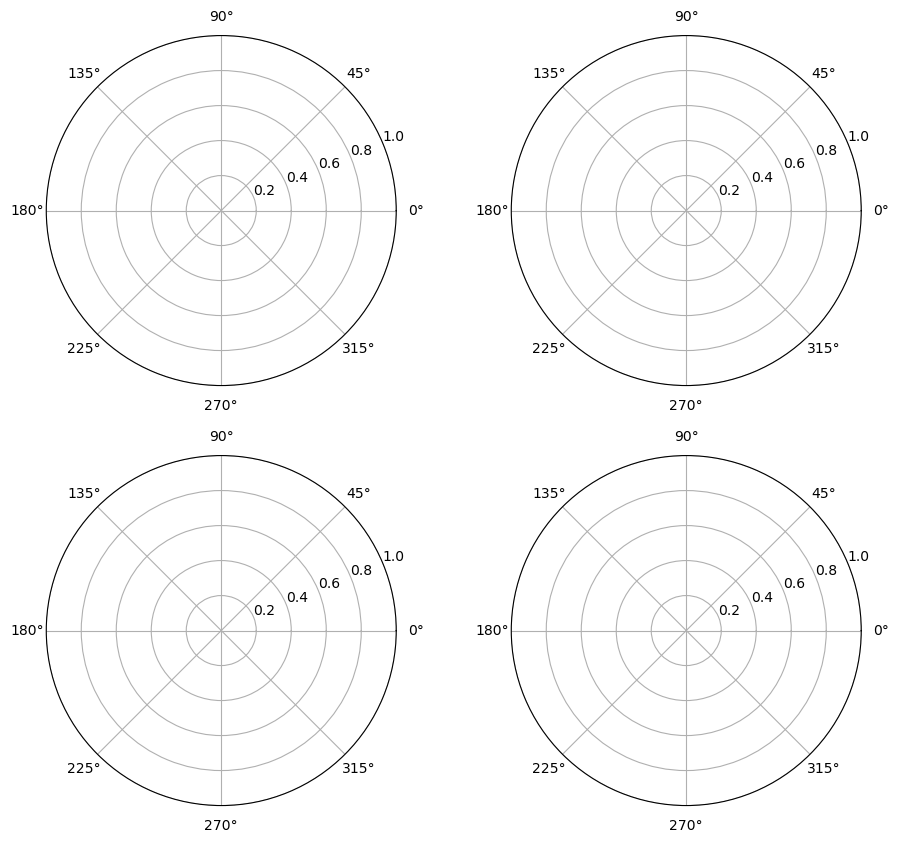

In [32]:
fig, axs = plt.subplots(2, 2, figsize=(11,10), subplot_kw={'projection': 'polar'})
dn = 'all' #d or n for day/night filter
sectors = 8

# #u*
# var = 'u*'
# min_val = 0
# max_val = 1
# rticks = [0, 0.25, .5]
# rmin, rmax = 0, 0.75
# cb_max = 100


# CO2
var = 'co2_flux'
min_val = -30
max_val = 15
rticks = [-20, -10, 0, 10]
rmin, rmax = -22, 15
cb_max = 62



bin_cents = calc_bin_cents(sectors)
towdict = {'KSA': KSA, 
           'KSC': KSC}
towlist = list(towdict.keys())

#plot circle
x_circ = np.linspace(0, 2*np.pi, 100)
y_circ = np.zeros(100)

dn_list = ['d', 'n']
cb = []
for i in range(len(towlist)):
    for j in range(len(dn_list)):
        
        tow = towlist[i]
        towdat = towdict[tow]
        ax = axs[j, i]
        dn = dn_list[j]
        
        y = towdat[var]
        filter = (y<=max_val) &(y>=min_val)
        y_filt = dn_filt(y.where(filter)[sd:ed], dn)
        x_filt = dn_filt(towdat['WD'].where(filter)[sd:ed], dn)*np.pi/180

        if dn =='d':
            daytime = 'Day'
        if dn =='n':
            daytime = 'Night'


        cb.append(ax.hist2d(x_filt, y_filt, bins = [12,25], range = [[0, 2*np.pi], [min_val, max_val]], cmap = 'Oranges', vmin = 0, vmax = cb_max))
       

        ax.set_rticks(rticks)
        ax.set_rlim(rmin, rmax)

        ax.tick_params(axis='y', colors='k')
        ax.set_theta_zero_location("N")
        ax.set_theta_direction(-1)
        ax.set_xticks(np.linspace(0, np.pi*7/4, 8))
        ax.set_xticklabels(['N', '', 'E', '', 'S', '', 'W', '']);
        ax.set_title(tow + ', ' + daytime, loc = 'left')
        ax.plot(x_circ, y_circ, c = colorlist[2])
        
fig.colorbar(cb[3][3], ax=axs.ravel().tolist(), 
             orientation='horizontal', fraction=0.04, pad=0.04,
             label='Frequency')

# plt.suptitle('$u_*$ vs. Wind Direction')
plt.suptitle('NEE vs. Wind Dire.ction')
# plt.tight_layout()

# plt.savefig(save_base_path + 'ustar_v_WD_heatmap.png')
plt.savefig(save_base_path + 'NEE_v_WD_heatmap.png')


## Code Junkyard

#### Linear boxplot by wind sector

In [ ]:
       
# fig, axs = plt.subplots(figsize=(10,5))
# sns.boxplot(ax = axs, x='Bin', y='Value', data=boxplot_df, color = colorlist[0])
# # 

# axs.set_xlabel('Wind Direction')
# axs.set_ylabel('NEE [$\mu mol/{m^2s}$]')
# axs.set_ylim(-40, 40)
# axs.tick_params(axis='x', labelrotation=45);
# fig.suptitle('KSA Wind Direction v. NEE')
# plt.tight_layout()
# plt.savefig(save_base_path + 'KSA_WD_v_NEE_lin.png')


Datalogger data plot code

In [ ]:
#Read in Datalogger data
# # KSC = rnf(base_dir1 + 'KSC_summer\\eddypro_KSC_full_output_2025-07-31T173612_adv.csv', dt_form = 'EP')
# # KSA = rnf(base_dir1 + 'KSA_summer\\eddypro_KSA_full_output_2025-07-31T194050_adv.csv', dt_form = 'EP')

# KSC = rnf('C:\\Users\\emily\\Documents\\Grad_School\\Research\\Agrivoltaics\\Data_processing\\Datalogger_output_fluxes\\2025_controltow_flux.csv', dt_form = 'DL')
# KSA = rnf('C:\\Users\\emily\\Documents\\Grad_School\\Research\\Agrivoltaics\\Data_processing\\Datalogger_output_fluxes\\2025_arraytow_flux.csv', dt_form = 'DL')

# base_dir2 = 'C:\\Users\\emily\\Documents\\Grad_School\\Research\\Agrivoltaics\\Data_processing\\Datalogger_output_fluxes\\'
# KSA_NR =rnf(base_dir2 + '2025_arraytow_netrad.csv', dt_form = 'DL')
# KSC_NR =rnf(base_dir2 + '2025_controltow_netrad.csv', dt_form = 'DL')


In [ ]:
# FC_unit_conv = 60 * 30 * 1e-6 * 44 #60 s/min * 30 min * 1 mol/10^6 micromol * 44 g/mol 
# # KSA_FC_cum = KSA['co2_flux'].where((KSA['co2_flux']>-50)&(KSA['co2_flux']<50)).cumsum()*FC_unit_conv
# # KSC_FC_cum = KSC['co2_flux'].where((KSC['co2_flux']>-50)&(KSC['co2_flux']<50)).cumsum()*FC_unit_conv

# KSA_FC_cum = KSA['Fc_wpl'].where((KSA['Fc_wpl']>-50)&(KSA['Fc_wpl']<50)).cumsum()*FC_unit_conv
# KSC_FC_cum = KSC['Fc_wpl'].where((KSC['Fc_wpl']>-50)&(KSC['Fc_wpl']<50)).cumsum()*FC_unit_conv


# KSA_FC_cum = KSA_FC_cum.where(np.isfinite(KSC_FC_cum))
# KSC_FC_cum = KSC_FC_cum.where(np.isfinite(KSA_FC_cum))

# plt.title('Cumulative CO2 Flux June 1-September 9 2025')
# plt.ylabel('Cumulative CO2 Flux [$g/m^2$]')

# plt.plot(KSA_FC_cum, label = 'Array', c = colorlist[5])
# plt.plot(KSC_FC_cum, label = 'Control', c = colorlist[10])
# plt.xticks(rotation = 45);
# plt.annotate(text = 'Vegetation \n mowed', xy = (dt.datetime(2025, 7, 2), -270), 
#              xytext= (dt.datetime(2025, 6, 18), -300), arrowprops=dict(facecolor='black', arrowstyle='->'))
# plt.legend();


In [ ]:
# # FC_unit_conv = 60 * 30 * 1e-6 * 44 #60 s/min * 30 min * 1 mol/10^6 micromol * 44 g/mol 
# # KSA_FC_cum = KSA['co2_flux'].where((KSA['co2_flux']>-50)&(KSA['co2_flux']<50)).cumsum()*FC_unit_conv
# # KSC_FC_cum = KSC['co2_flux'].where((KSC['co2_flux']>-50)&(KSC['co2_flux']<50)).cumsum()*FC_unit_conv

# var = 'LE_wpl'
# varmin = -100
# varmax = 800
# avg_per = '1d'
# KSA_LE = KSA[var].where((KSA[var]>varmin)&(KSA[var]<varmax)).resample(avg_per).mean()
# KSC_LE = KSC[var].where((KSC[var]>varmin)&(KSC[var]<varmax)).resample(avg_per).mean()

# var = 'Fc_wpl'
# varmin = -200
# varmax = 600
# avg_per = '7d'
# KSA_H = KSA[var].where((KSA[var]>varmin)&(KSA[var]<varmax)).resample(avg_per).mean()
# KSC_H = KSC[var].where((KSC[var]>varmin)&(KSC[var]<varmax)).resample(avg_per).mean()


# # KSA_FC_cum = KSA_FC_cum.where(np.isfinite(KSC_FC_cum))
# # KSC_FC_cum = KSC_FC_cum.where(np.isfinite(KSA_FC_cum))

# plt.title('Cumulative CO2 Flux June 1-September 9 2025')
# plt.ylabel('Cumulative CO2 Flux [$g/m^2$]')

# # plt.plot(KSA_LE, label = 'Array', c = colorlist[5])
# # plt.plot(KSC_LE, label = 'Control', c = colorlist[10])

# plt.plot(KSA_H, label = 'Array', c = colorlist[5])
# plt.plot(KSC_H, label = 'Control', c = colorlist[10])

# plt.xticks(rotation = 45);
# plt.legend();

In [ ]:
# plt.plot(KSA['LE_wpl'].where((KSA['LE_wpl']>-100)&(KSA['LE_wpl']<800)))